# Feature Engineering

## Introduction

In the previous steps, we explored the dataset and looked at how variables relate to each other. This helped identify dependencies, redundancy, and groups of features that describe similar aspects of customer behavior.

Some preprocessing steps were already done during the exploratory phase, such as handling missing values and basic transformations. We also removed a few variables that were clearly redundant based on their relationships with others.

At this point, the focus shifts to refining the remaining features.

In particular, we saw that several categorical variables, especially those related to additional services, are strongly associated. These features are not independent, but at the same time they cannot simply be removed, as each of them still carries useful information.

This means that the problem is no longer about removing variables, but about representing them in a more meaningful way.

In this notebook, we focus on transforming the dataset based on these observations. This includes:

- consolidating related categorical features  
- exploring transformations of numerical variables  
- and preparing features in a form suitable for modeling  

The goal is not to apply generic preprocessing steps, but to make decisions that reflect the structure observed in the data.

## Table of Contents

1. [Recapitulation](#recapitulation-of-previous-data-manipulations)
2. [Domain knowledge Engineering](#categorical-feature-associations)
    - [Internet Services](#internet-services)
    - [tenure](#tenure)
    - [MonthlyCharges](#monthly-charges)
3. [Autmated Engineering](#automated-feature-engineering)
    - [Releveling](#releveling-of-multiplelines)
4. [Conclusion](#final-conclusion)

## Recapitulation of Previous Data Manipulations

Before proceeding, it is useful to briefly recap the preprocessing steps that were already applied in earlier stages of the analysis.

In previous steps:

- `CustomerID` was removed, as it represents a unique identifier and does not carry predictive information.
- `gender` was excluded due to potential regulatory and ethical considerations, even if it may contain predictive signal.
- `SeniorCitizen` was transformed from a binary numeric variable (`0`, `1`) to a categorical representation (`no`, `yes`) to maintain consistency with other features.
- `MultipleLines` was removed, due to weak relationship with `churn`.
- `TotalCharges` missing values were handled during EDA. The variable was later removed due to its strong dependency on `tenure` and `MonthlyCharges`, making it redundant.

These steps provide the current starting point for feature engineering.

## Domain Knowledge Engineering

At this stage, the focus is on feature transformations that are guided by the structure observed in the data, rather than applying fully automated approaches.

In the previous analysis, two areas stood out as requiring more careful treatment:

- service-related categorical variables, which are strongly associated and describe similar aspects of customer behavior  
- tenure, which is a key numerical variable but may not be well represented in its current form  

For service-related features, the goal is to explore ways to group or aggregate them so that they capture the overall level of service adoption without introducing unnecessary redundancy.

For tenure, the question is how to best represent its relationship with churn. This may involve considering both continuous and categorical representations, as well as potential transformations such as logarithmic scaling.

Rather than applying a single predefined transformation, the approach in this section is to explore different representations and determine which ones best reflect the underlying behavior of the data.



### Internet Services

From the previous analysis, it was clear that service-related variables are strongly associated and often appear together. These features are not independent, but at the same time each of them represents a specific service, so removing them would mean losing useful information.

This creates a question of how to represent this part of the data in a more meaningful way.

One option is to keep all the detail and combine the variables into a single categorical feature that captures all possible service combinations. This would preserve the full information, but would also result in a large number of categories.

Another option is to simplify the structure by grouping services. For example, internet-related services and streaming services can be treated separately, as they showed slightly different behavior in relation to churn. In this case, the number of services within each group can be used instead of individual variables.

A more simplified approach is to represent the total number of additional services a customer has.

These approaches naturally reduce the amount of information compared to the original variables, so they are not expected to perform better in a strict sense. The goal is rather to see whether a simpler representation can capture a similar information without introducing unnecessary complexity.

In this section, different representations of service-related features are explored and compared to better understand this trade-off.

**Recapturing Original Variable**

In [1]:
import polars as pl

df_fe_start = pl.read_csv("data/processed/04_ram_train_df_end.csv")

In [2]:
df_fe_start.columns

['SeniorCitizenRelevel',
 'Partner',
 'Dependents',
 'tenure',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'Churn']

In [3]:
additional_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]

streaming_cols = [
    "StreamingTV",
    "StreamingMovies"
]

At this stage, the goal is not to simplify the original structure yet, but to reorganize it into a form that is easier to reason about.

For this purpose, two new variables are created:

- `AdditionalInternetServices`, capturing all combinations of `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, and `TechSupport`
- `StreamingServices`, capturing all combinations of `StreamingTV` and `StreamingMovies`

By doing this, the original information is not reduced. The same service patterns are still preserved, only represented in a different form.

Because of that, this transformation should be logically equivalent to the original set of variables and is not expected to reduce predictive signal on its own. The value of this step is mainly in making the structure more explicit and creating a clearer starting point for comparing more simplified representations later.

In [4]:
df_fe_internet_services = df_fe_start.with_columns(
    pl.when(pl.col("InternetService") == "No")
    .then(pl.lit("No additional services"))
    .otherwise(
        pl.when(
            pl.concat_str(
                [
                    pl.when(pl.col(col) == "Yes")
                    .then(pl.lit(col))
                    .otherwise(None)
                    for col in additional_cols
                ],
                separator=" + ",
                ignore_nulls=True
            ) == ""
        )
        .then(pl.lit("No additional services"))
        .otherwise(
            pl.concat_str(
                [
                    pl.when(pl.col(col) == "Yes")
                    .then(pl.lit(col))
                    .otherwise(None)
                    for col in additional_cols
                ],
                separator=" + ",
                ignore_nulls=True
            )
        )
    )
    .alias("AdditionalInternetServices")
)

In [5]:
df_fe_internet_services = df_fe_internet_services.with_columns(
    pl.when(pl.col("InternetService") == "No")
    .then(pl.lit("No streaming services"))
    .otherwise(
        pl.when(
            pl.concat_str(
                [
                    pl.when(pl.col(col) == "Yes")
                    .then(pl.lit(col))
                    .otherwise(None)
                    for col in streaming_cols
                ],
                separator=" + ",
                ignore_nulls=True
            ) == ""
        )
        .then(pl.lit("No streaming services"))
        .otherwise(
            pl.concat_str(
                [
                    pl.when(pl.col(col) == "Yes")
                    .then(pl.lit(col))
                    .otherwise(None)
                    for col in streaming_cols
                ],
                separator=" + ",
                ignore_nulls=True
            )
        )
    )
    .alias("StreamingServices")
)

At this stage, the `No internet service` category is no longer kept as a separate outcome within this variable.

While it was useful in the initial restructuring to make the full structure explicit, this information is already captured by the `InternetService` feature itself. Including it again would therefore introduce redundancy without adding new information.

For this reason, customers without internet service are grouped together with those who have no additional services under a single `No additional services` category (and streaming services with `No streaming services`). The distinction between these cases remains available through `InternetService`.

In [6]:
df_fe_internet_services.head()

SeniorCitizenRelevel,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,AdditionalInternetServices,StreamingServices
str,str,str,i64,str,str,str,str,str,str,str,str,str,str,f64,str,str,str
"""No""","""No""","""No""",2,"""DSL""","""Yes""","""Yes""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Mailed check""",53.85,"""Yes""","""OnlineSecurity + OnlineBackup""","""No streaming services"""
"""No""","""No""","""No""",2,"""Fiber optic""","""No""","""No""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Electronic check""",70.7,"""Yes""","""No additional services""","""No streaming services"""
"""No""","""No""","""No""",8,"""Fiber optic""","""No""","""No""","""Yes""","""No""","""Yes""","""Yes""","""Month-to-month""","""Yes""","""Electronic check""",99.65,"""Yes""","""DeviceProtection""","""StreamingTV + StreamingMovies"""
"""No""","""Yes""","""No""",28,"""Fiber optic""","""No""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""Month-to-month""","""Yes""","""Electronic check""",104.8,"""Yes""","""DeviceProtection + TechSupport""","""StreamingTV + StreamingMovies"""
"""No""","""No""","""No""",49,"""Fiber optic""","""No""","""Yes""","""Yes""","""No""","""Yes""","""Yes""","""Month-to-month""","""Yes""","""Bank transfer (automatic)""",103.7,"""Yes""","""OnlineBackup + DeviceProtectio…","""StreamingTV + StreamingMovies"""


In [7]:
pl.Config.set_tbl_rows(-1)
df_fe_internet_services["AdditionalInternetServices"].value_counts()

AdditionalInternetServices,count
str,u32
"""OnlineBackup + DeviceProtectio…",301
"""OnlineSecurity + OnlineBackup""",168
"""OnlineSecurity + DeviceProtect…",189
"""DeviceProtection + TechSupport""",185
"""OnlineBackup + DeviceProtectio…",199
"""OnlineSecurity + TechSupport""",136
"""DeviceProtection""",360
"""No additional services""",2248
"""OnlineSecurity + OnlineBackup …",183


In [8]:
df_fe_internet_services["StreamingServices"].value_counts()

StreamingServices,count
str,u32
"""StreamingMovies""",623
"""No streaming services""",2840
"""StreamingTV + StreamingMovies""",1560
"""StreamingTV""",611


In [9]:
pl.Config.restore_defaults()

polars.config.Config

A quick look at the distribution of the newly created variables shows that most customers fall into a relatively small number of categories.

For additional internet services, a large portion of customers have no additional services, while the remaining observations are spread across many different combinations. This results in a high number of categories with relatively low counts, reflecting the combinatorial nature of the feature.

For streaming services, the distribution is more concentrated. Most customers either have no streaming services or use both `StreamingTV` and `StreamingMovies`, with fewer customers subscribing to only one of them.

This highlights the difference between the two groups: additional services are more fragmented across many combinations, while streaming services show a more structured pattern. This difference will be useful when considering simpler representations in the next steps.

**Additional Services Count**

After restructuring the original service variables into explicit combinations, the next step is to test a simpler representation.

Instead of keeping the exact combination of additional internet services, the information can be reduced to the number of subscribed services, ranging from 0 to 4.

This removes the distinction between specific combinations, but still preserves the overall level of service adoption. In other words, it no longer captures *which* services a customer has, but still captures *how many* additional internet services are being used.

This provides a more compact representation and makes it possible to check whether the detailed structure is really needed, or whether a simpler count-based feature can capture a similar information.

In [10]:
df_fe_internet_services = df_fe_internet_services.with_columns(
    pl.when(pl.col("InternetService") == "No")
    .then(0)
    .otherwise(
        (
            (pl.col("OnlineSecurity") == "Yes").cast(pl.Int8) +
            (pl.col("OnlineBackup") == "Yes").cast(pl.Int8) +
            (pl.col("DeviceProtection") == "Yes").cast(pl.Int8) +
            (pl.col("TechSupport") == "Yes").cast(pl.Int8)
        )
    )
    .alias("AdditionalInternetServicesCount")
)

In [11]:
df_fe_internet_services = df_fe_internet_services.with_columns(
    pl.when(pl.col("InternetService") == "No")
    .then(0)
    .otherwise(
        (
            (pl.col("StreamingTV") == "Yes").cast(pl.Int8) +
            (pl.col("StreamingMovies") == "Yes").cast(pl.Int8)
        )
    )
    .alias("StreamingServicesCount")
)

In [12]:
df_fe_internet_services.head()

SeniorCitizenRelevel,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,AdditionalInternetServices,StreamingServices,AdditionalInternetServicesCount,StreamingServicesCount
str,str,str,i64,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,i8,i8
"""No""","""No""","""No""",2,"""DSL""","""Yes""","""Yes""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Mailed check""",53.85,"""Yes""","""OnlineSecurity + OnlineBackup""","""No streaming services""",2,0
"""No""","""No""","""No""",2,"""Fiber optic""","""No""","""No""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Electronic check""",70.7,"""Yes""","""No additional services""","""No streaming services""",0,0
"""No""","""No""","""No""",8,"""Fiber optic""","""No""","""No""","""Yes""","""No""","""Yes""","""Yes""","""Month-to-month""","""Yes""","""Electronic check""",99.65,"""Yes""","""DeviceProtection""","""StreamingTV + StreamingMovies""",1,2
"""No""","""Yes""","""No""",28,"""Fiber optic""","""No""","""No""","""Yes""","""Yes""","""Yes""","""Yes""","""Month-to-month""","""Yes""","""Electronic check""",104.8,"""Yes""","""DeviceProtection + TechSupport""","""StreamingTV + StreamingMovies""",2,2
"""No""","""No""","""No""",49,"""Fiber optic""","""No""","""Yes""","""Yes""","""No""","""Yes""","""Yes""","""Month-to-month""","""Yes""","""Bank transfer (automatic)""",103.7,"""Yes""","""OnlineBackup + DeviceProtectio…","""StreamingTV + StreamingMovies""",2,2


In [13]:
df_fe_internet_services["AdditionalInternetServicesCount"].value_counts()

AdditionalInternetServicesCount,count
i8,u32
4,394
2,1078
3,743
0,2248
1,1171


In [14]:
df_fe_internet_services["StreamingServicesCount"].value_counts()

StreamingServicesCount,count
i8,u32
1,1234
2,1560
0,2840


The distributions of the aggregated service variables highlight a clear difference between the two groups.

For additional internet services, most customers fall into lower to mid ranges, with the largest group having no additional services, followed by customers with one or two services. At the same time, the distribution remains relatively spread out across multiple levels.

In contrast, streaming services show a more concentrated pattern, with most customers either having no streaming services or using both, and a smaller group subscribing to only one.

Although both variables are numerical by construction (0–4 and 0–2), they will be treated as categorical features in the following steps.

While the numeric form captures the overall level of service adoption, representing these variables as categorical allows the model to treat each level separately, without assuming a strictly linear relationship between the number of services and churn. This is useful, as the difference between individual levels may not be uniform.

## Comparing Feature Representations

At this stage, multiple representations of service-related features have been created, ranging from detailed combinations to more compact aggregated forms.

The goal is not to determine which representation is best in absolute terms, but to understand how much predictive predictive information is retained when simplifying the feature space.

To evaluate this, logistic regression models are trained using different combinations of features. A 5-fold cross-validation approach is used to obtain stable performance estimates.

The comparison starts with the most detailed representation and progressively replaces parts of it with simplified versions, allowing us to observe how each transformation affects model performance.

In [15]:
import numpy as np
import polars as pl
# for logistic regression
import statsmodels.api as sm

# for train test split and auc
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
# for log likelihood ratio test
from scipy.stats import chi2

In [16]:
def build_matrix(
    df: pl.DataFrame,
    categorical_cols: list[str],
    numerical_cols: list[str],
    drop_first: bool = True
) -> tuple[np.ndarray, list[str]]:
    """
    Construct a design matrix for modeling from a Polars DataFrame.

    This function prepares the feature matrix by:
    - one-hot encoding categorical variables
    - keeping numerical variables as-is
    - combining both into a single matrix suitable for modeling

    Parameters
    ----------
    df : pl.DataFrame
        Input dataset containing feature columns.

    categorical_cols : list[str]
        List of column names to be treated as categorical and one-hot encoded.

    numerical_cols : list[str]
        List of column names to be treated as numerical and used directly.

    drop_first : bool, default=True
        Whether to drop the first category in one-hot encoding to avoid
        multicollinearity.

    Returns
    -------
    X : np.ndarray
        The resulting feature matrix.

    feature_names : list[str]
        Names of the generated features after encoding.
    """
    parts = []

    if categorical_cols:
        # ensure the categorical columns are treated as strings for one-hot encoding
        cat_df = df.select(
            [pl.col(col).cast(pl.String) for col in categorical_cols]
        )

        dummies = cat_df.to_dummies(drop_first=drop_first)
        parts.append(dummies)

    if numerical_cols:
        parts.append(df.select(numerical_cols))

    X_df = pl.concat(parts, how="horizontal") if parts else pl.DataFrame()
    X = X_df.to_numpy()
    feature_names = X_df.columns

    return X, feature_names

In [17]:
def fit_logit_and_score(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_valid: np.ndarray,
    y_valid: np.ndarray
):
    """
    Fit a logistic regression model and evaluate it on validation data.

    The model is fitted using statsmodels' Logit implementation.
    Performance is evaluated using AUC, while model fit is captured
    through log-likelihood and BIC.

    Parameters
    ----------
    X_train : np.ndarray
        Training feature matrix.

    y_train : np.ndarray
        Training target values (binary).

    X_valid : np.ndarray
        Validation feature matrix.

    y_valid : np.ndarray
        Validation target values (binary).

    Returns
    -------
    dict
        Dictionary containing:
        - result : fitted statsmodels result object
        - auc : AUC score on validation data
        - bic : Bayesian Information Criterion of the model
        - llf : log-likelihood of the fitted model
    """
    X_train_const = sm.add_constant(X_train, has_constant="add")
    X_valid_const = sm.add_constant(X_valid, has_constant="add")

    model = sm.Logit(y_train, X_train_const)
    result = model.fit(disp=False)

    y_valid_pred = result.predict(X_valid_const)
    auc = roc_auc_score(y_valid, y_valid_pred)

    return {
        "result": result,
        "auc": auc,
        "bic": result.bic,
        "llf": result.llf
    }

In [18]:
def likelihood_ratio_test(full_result, reduced_result):
    """
    Perform a likelihood ratio test between two nested models.

    The test evaluates whether the reduced (simplified) model
    significantly worsens model fit compared to the full model.

    The test statistic follows a chi-square distribution, where
    degrees of freedom correspond to the difference in number
    of parameters between the two models.

    Parameters
    ----------
    full_result : statsmodels result object
        Fitted model representing the more complex (full) model.

    reduced_result : statsmodels result object
        Fitted model representing the simpler (reduced) model.

    Returns
    -------
    dict
        Dictionary containing:
        - lr_stat : likelihood ratio statistic
        - df_diff : difference in degrees of freedom
        - p_value : p-value of the test
    """

    lr_stat = 2 * (full_result.llf - reduced_result.llf)
    df_diff = full_result.df_model - reduced_result.df_model
    p_value = chi2.sf(lr_stat, df_diff)

    return {
        "lr_stat": float(lr_stat),
        "df_diff": float(df_diff),
        "p_value": float(p_value)
    }

In [19]:
def cross_validate_logit(
    df: pl.DataFrame,
    target_col: str,
    categorical_cols: list[str],
    numerical_cols: list[str],
    baseline_categorical_cols: list[str] | None = None,
    baseline_numerical_cols: list[str] | None = None,
    n_splits: int = 5,
    random_state: int = 42
) -> pl.DataFrame:
    """
    Perform stratified k-fold cross-validation for logistic regression models.

    This function evaluates a given feature representation by:
    - splitting the data into k folds
    - training the model on k-1 folds
    - validating on the remaining fold
    - repeating this process across all folds

    Optionally, a baseline model can be provided for comparison using
    likelihood ratio testing.

    Parameters
    ----------
    df : pl.DataFrame
        Input dataset containing features and target.

    target_col : str
        Name of the target column (binary classification).

    categorical_cols : list[str]
        Categorical features to include in the model.

    numerical_cols : list[str]
        Numerical features to include in the model.

    baseline_categorical_cols : list[str], optional
        Categorical features for the baseline (full) model.

    baseline_numerical_cols : list[str], optional
        Numerical features for the baseline model.

    n_splits : int, default=5
        Number of cross-validation folds.

    random_state : int, default=42
        Random seed for reproducibility.

    Returns
    -------
    pl.DataFrame
        DataFrame containing fold-level evaluation metrics:
        - AUC
        - BIC
        - log-likelihood
        - optional likelihood ratio test results
    """

    y = (df[target_col] == "Yes").cast(pl.Int8).to_numpy()

    #get k-fold splits
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    rows = []

    # iterate over folds and evaluate model performance
    for fold, (train_idx, valid_idx) in enumerate(skf.split(np.zeros(len(y)), y), start=1):
        df_train = df[train_idx]
        df_valid = df[valid_idx]

        X_train, _ = build_matrix(df_train, categorical_cols, numerical_cols)
        X_valid, _ = build_matrix(df_valid, categorical_cols, numerical_cols)

        y_train = y[train_idx]
        y_valid = y[valid_idx]

        current_metrics = fit_logit_and_score(X_train, y_train, X_valid, y_valid)

        row = {
            "fold": fold,
            "auc": current_metrics["auc"],
            "bic": current_metrics["bic"],
            "llf": current_metrics["llf"]
        }

        # Note:
        # The baseline model is re-fitted for each fold and for each comparison.
        # This is not the most computationally efficient approach, as the same
        # baseline model could be reused within each fold.
        #
        # However, for clarity and consistency of the comparison setup, the models
        # are fitted independently in each case. Given the relatively small dataset,
        # the additional computational cost is acceptable in this context.

        if baseline_categorical_cols is not None or baseline_numerical_cols is not None:
            X_train_base, _ = build_matrix(
                df_train,
                baseline_categorical_cols or [],
                baseline_numerical_cols or []
            )
            X_valid_base, _ = build_matrix(
                df_valid,
                baseline_categorical_cols or [],
                baseline_numerical_cols or []
            )

            baseline_metrics = fit_logit_and_score(
                X_train_base, y_train, X_valid_base, y_valid
            )

            lrt = likelihood_ratio_test(
                full_result=baseline_metrics["result"],
                reduced_result=current_metrics["result"]
            )

            row["baseline_auc"] = baseline_metrics["auc"]
            row["baseline_bic"] = baseline_metrics["bic"]
            row["baseline_llf"] = baseline_metrics["llf"]
            row["lr_stat"] = lrt["lr_stat"]
            row["lr_df_diff"] = lrt["df_diff"]
            row["lr_p_value"] = lrt["p_value"]

        rows.append(row)

    return pl.DataFrame(rows)

We have our helper function in place and now let's run the comparisons.

### Comparisons to full baseline model

In this section, the simplified ("challenger") models are compared against the full baseline model, which contains the complete set of service-related information.

The goal is to understand how much predictive signal is lost when moving from a detailed representation to more compact feature constructions.

While the models are not strictly nested due to differences in feature representation, they can still be compared using several complementary metrics.

Model performance is evaluated using AUC as an indicator of predictive power, where higher values indicate better discrimination between churn and non-churn.

Log-likelihood and the likelihood ratio test are used to assess differences in model fit. In this context, a low p-value (below the chosen significance level, usually selected as 0.05) indicates that the simplified model fits the data significantly worse than the baseline, while a higher p-value suggests that the simpler model is sufficient.

Finally, BIC is used to account for model complexity, where lower values are preferred, as it penalizes models with a large number of parameters.

Together, these metrics allow evaluating not only whether differences exist, but also whether they are practically meaningful given the trade-off between model complexity and performance.

**Baseline vs AdditionalInternetServicesCount**

In [20]:
baseline_cat = [
    "InternetService",
    "AdditionalInternetServices",
    "StreamingServices"
]

baseline_num = []

model_2_cat = [
    "InternetService",
    "AdditionalInternetServicesCount",
    "StreamingServices"
]

model_2_num = []

cv_model_2 = cross_validate_logit(
    df=df_fe_internet_services,
    target_col="Churn",
    categorical_cols=model_2_cat,
    numerical_cols=model_2_num,
    baseline_categorical_cols=baseline_cat,
    baseline_numerical_cols=baseline_num,
    n_splits=5,
    random_state=42
)

cv_model_2

fold,auc,bic,llf,baseline_auc,baseline_bic,baseline_llf,lr_stat,lr_df_diff,lr_p_value
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,0.757907,4346.046481,-2130.956305,0.765242,4410.090478,-2116.704675,28.50326,11.0,0.002709
2,0.769413,4318.673015,-2117.269572,0.722402,4386.983584,-2105.151228,24.236688,11.0,0.011771
3,0.665596,4307.750481,-2111.808305,0.646101,4380.966207,-2102.14254,19.331532,11.0,0.055396
4,0.628653,4376.999237,-2146.432684,0.679132,4453.283673,-2138.301273,16.262821,11.0,0.131651
5,0.601485,4351.853898,-2133.858905,0.620132,4417.999269,-2120.656741,26.404327,11.0,0.005648


The comparison shows that simplifying the representation of additional internet services leads to a measurable loss of information.

This is reflected in lower AUC values and consistently worse log-likelihood compared to the full model. The likelihood ratio test further confirms that the simplified model fits the data significantly worse, indicating that some information is indeed lost when moving away from the full set of service combinations.

At the same time, the simplified model achieves lower BIC values. This suggests that, while the full model captures more detail, the improvement in fit may not justify the additional complexity introduced by a large number of categories.

Taken together, these results highlight a trade-off between model complexity and predictive performance. The full representation provides a better fit, but the simplified version offers a more compact and interpretable structure.

For the purpose of this analysis, the simpler representation will be used in the following steps, as it provides a reasonable balance while remaining easier to interpret and work with.

**Baseline vs StreamingServicesCount**

In [21]:
baseline_cat = [
    "InternetService",
    "AdditionalInternetServices",
    "StreamingServices"
]

baseline_num = []

model_3_cat = [
    "InternetService",
    "AdditionalInternetServices",
    "StreamingServicesCount"
]

model_3_num = []

cv_model_3 = cross_validate_logit(
    df=df_fe_internet_services,
    target_col="Churn",
    categorical_cols=model_3_cat,
    numerical_cols=model_3_num,
    baseline_categorical_cols=baseline_cat,
    baseline_numerical_cols=baseline_num,
    n_splits=5,
    random_state=42
)

cv_model_3

fold,auc,bic,llf,baseline_auc,baseline_bic,baseline_llf,lr_stat,lr_df_diff,lr_p_value
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,0.766092,4401.898148,-2116.815204,0.765242,4410.090478,-2116.704675,0.221057,1.0,0.638236
2,0.721291,4378.642362,-2105.187311,0.722402,4386.983584,-2105.151228,0.072164,1.0,0.788211
3,0.646297,4372.595226,-2102.163743,0.646101,4380.966207,-2102.14254,0.042406,1.0,0.836848
4,0.679227,4445.892105,-2138.812182,0.679132,4453.283673,-2138.301273,1.021818,1.0,0.312088
5,0.620644,4409.638969,-2120.683396,0.620132,4417.999269,-2120.656741,0.053308,1.0,0.817403


In contrast to additional internet services, simplifying the representation of streaming services does not result in a meaningful loss of information.

The AUC values remain effectively unchanged, and the log-likelihood is nearly identical to the full model. The likelihood ratio test further confirms that the simplified model does not fit the data significantly worse, indicating that the detailed combinations do not provide additional explanatory power in this case.

At the same time, the simplified representation achieves lower BIC values, suggesting that the reduced complexity is beneficial without sacrificing model performance.

This indicates that, unlike additional services, streaming services can be effectively represented using a simple count-based feature without losing relevant information.

For this reason, the simplified representation will be used in the following steps.

Note: This aligns with earlier observations from the exploratory analysis, where streaming services showed a more structured and less fragmented pattern compared to other service-related variables.

**Baseline vs StreamingServicesCount + AdditionalServicesServicesCount**

In [22]:
baseline_cat = [
    "InternetService",
    "AdditionalInternetServices",
    "StreamingServices"
]

baseline_num = []

model_4_cat = [
    "InternetService",
    "AdditionalInternetServicesCount",
    "StreamingServicesCount"
]

model_4_num = []

cv_model_4 = cross_validate_logit(
    df=df_fe_internet_services,
    target_col="Churn",
    categorical_cols=model_4_cat,
    numerical_cols=model_4_num,
    baseline_categorical_cols=baseline_cat,
    baseline_numerical_cols=baseline_num,
    n_splits=5,
    random_state=42
)

cv_model_4

fold,auc,bic,llf,baseline_auc,baseline_bic,baseline_llf,lr_stat,lr_df_diff,lr_p_value
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,0.7584,4337.898319,-2131.088918,0.765242,4410.090478,-2116.704675,28.768486,12.0,0.004264
2,0.769305,4310.320433,-2117.299975,0.722402,4386.983584,-2105.151228,24.297493,12.0,0.018526
3,0.665178,4299.350868,-2111.815192,0.646101,4380.966207,-2102.14254,19.345305,12.0,0.080529
4,0.628601,4369.491637,-2146.885577,0.679132,4453.283673,-2138.301273,17.168608,12.0,0.143364
5,0.601159,4343.481132,-2133.879326,0.620132,4417.999269,-2120.656741,26.44517,12.0,0.009279


When both service groups are simplified to count-based representations, the results show a similar pattern to the case of additional internet services alone.

The AUC values decrease compared to the full model, and the log-likelihood is consistently worse. The likelihood ratio test also indicates that the simplified model fits the data significantly worse, confirming that some information is lost when replacing detailed service combinations with counts.

At the same time, the simplified model achieves lower BIC values, suggesting that the reduction in complexity is beneficial from a model selection perspective.

This again highlights the trade-off between model simplicity and predictive performance. While the full representation captures more detailed information, the count-based representation still provides a more compact and interpretable structure.

Consistent with the earlier decision, the simplified representation will be used in the following steps, as it offers a more practical balance between complexity and usability.

**Summary of comparisons on full model**

At this stage, the simplified representation of service-related features has been evaluated against the full model and shown to provide a reasonable balance between model fit and complexity.

While some loss of information is observed compared to the full representation, the simplified variables offer a more compact and interpretable structure, with lower BIC values indicating that the reduction in complexity is justified.

For this reason, the simplified representation is adopted as the new baseline for the following steps, and further feature transformations will be evaluated relative to this version of the dataset.

### Selected model further simplifications

At this stage, the simplified count-based representations are used as the new baseline.

The next step is to examine whether these variables need to be treated as categorical, or whether they can be represented as continuous features.

Using a numeric representation introduces an assumption of a linear relationship between the number of services and churn. This may simplify the model further, but could also result in a loss of information if the relationship is not uniform across levels.

To evaluate this, the count-based variables are tested both individually and jointly in their numeric form and compared against the categorical baseline.

**Selected model vs AdditionalInternetServicesCount numeric**

In [23]:
baseline_cat = [
    "InternetService",
    "AdditionalInternetServicesCount",
    "StreamingServicesCount"
]

baseline_num = []

model_5_cat = [
    "InternetService",
    "StreamingServicesCount"
]

model_5_num = ["AdditionalInternetServicesCount"]

cv_model_5 = cross_validate_logit(
    df=df_fe_internet_services,
    target_col="Churn",
    categorical_cols=model_5_cat,
    numerical_cols=model_5_num,
    baseline_categorical_cols=baseline_cat,
    baseline_numerical_cols=baseline_num,
    n_splits=5,
    random_state=42
)

cv_model_5

fold,auc,bic,llf,baseline_auc,baseline_bic,baseline_llf,lr_stat,lr_df_diff,lr_p_value
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,0.784558,4313.032448,-2131.276063,0.7584,4337.898319,-2131.088918,0.37429,3.0,0.945501
2,0.770449,4285.745905,-2117.632791,0.769305,4310.320433,-2117.299975,0.665632,3.0,0.881256
3,0.661955,4274.732328,-2112.126003,0.665178,4299.350868,-2111.815192,0.621621,3.0,0.891465
4,0.705417,4345.39468,-2147.457179,0.628601,4369.491637,-2146.885577,1.143205,3.0,0.766656
5,0.717909,4320.376817,-2134.947582,0.601159,4343.481132,-2133.879326,2.136511,3.0,0.544562


The results indicate that representing service counts as continuous variables does not lead to a loss of information compared to the categorical baseline.

The AUC values remain comparable, and the log-likelihood shows no meaningful deterioration in model fit. The likelihood ratio test further confirms that the numeric representation does not significantly worsen the model, as high p-values indicate that the simpler specification is sufficient.

At the same time, the model achieves lower BIC values, suggesting that the reduction in the number of parameters is beneficial.

This implies that the relationship between the number of services and churn can be adequately captured using a continuous representation, without the need to model each level separately.

For this reason, the continuous representation will be used in the following steps, as it provides a simpler and more efficient formulation without sacrificing predictive performance.

**Selected model vs StreamingServicesCount numeric**

In [24]:
baseline_cat = [
    "InternetService",
    "AdditionalInternetServicesCount",
    "StreamingServicesCount"
]

baseline_num = []

model_6_cat = [
    "InternetService",
    "AdditionalInternetServicesCount"
]

model_6_num = ["StreamingServicesCount"]

cv_model_6 = cross_validate_logit(
    df=df_fe_internet_services,
    target_col="Churn",
    categorical_cols=model_6_cat,
    numerical_cols=model_6_num,
    baseline_categorical_cols=baseline_cat,
    baseline_numerical_cols=baseline_num,
    n_splits=5,
    random_state=42
)

cv_model_6

fold,auc,bic,llf,baseline_auc,baseline_bic,baseline_llf,lr_stat,lr_df_diff,lr_p_value
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,0.758367,4329.496231,-2131.094567,0.7584,4337.898319,-2131.088918,0.011299,1.0,0.915348
2,0.771992,4304.500754,-2118.596829,0.769305,4310.320433,-2117.299975,2.593708,1.0,0.107289
3,0.668054,4291.36174,-2112.027322,0.665178,4299.350868,-2111.815192,0.424259,1.0,0.514819
4,0.630269,4361.663703,-2147.178303,0.628601,4369.491637,-2146.885577,0.585453,1.0,0.444183
5,0.600747,4335.736795,-2134.213962,0.601159,4343.481132,-2133.879326,0.669272,1.0,0.413306


lthough the numeric representation occasionally shows slightly higher AUC values compared to the baseline, these differences are not consistent across folds and are not supported by other metrics.

The log-likelihood remains very similar, and the likelihood ratio test indicates that there is no statistically significant difference between the models. This suggests that the observed improvements in AUC are likely due to random variation introduced by the cross-validation splits rather than a true improvement in model performance.

At the same time, the numeric representation achieves lower BIC values, indicating that the simpler model is preferable when accounting for complexity.

Taken together, these results support the conclusion that the continuous representation is sufficient, and the additional flexibility of the categorical version is not required.

**Selected model vs StreamingServicesCount numeric + AdditionalInternetServicesCount numeric**

In [25]:
baseline_cat = [
    "InternetService",
    "AdditionalInternetServicesCount",
    "StreamingServicesCount"
]

baseline_num = []

model_6_cat = [
    "InternetService"
]

model_6_num = ["StreamingServicesCount",
    "AdditionalInternetServicesCount"]

cv_model_6 = cross_validate_logit(
    df=df_fe_internet_services,
    target_col="Churn",
    categorical_cols=model_6_cat,
    numerical_cols=model_6_num,
    baseline_categorical_cols=baseline_cat,
    baseline_numerical_cols=baseline_num,
    n_splits=5,
    random_state=42
)

cv_model_6

fold,auc,bic,llf,baseline_auc,baseline_bic,baseline_llf,lr_stat,lr_df_diff,lr_p_value
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,0.784558,4304.627374,-2131.28022,0.7584,4337.898319,-2131.088918,0.382604,4.0,0.983876
2,0.773882,4279.88856,-2118.910812,0.769305,4310.320433,-2117.299975,3.221674,4.0,0.521437
3,0.66437,4266.718244,-2112.325654,0.665178,4299.350868,-2111.815192,1.020925,4.0,0.906607
4,0.705417,4337.529625,-2147.731345,0.628601,4369.491637,-2146.885577,1.691536,4.0,0.792255
5,0.718455,4312.567085,-2135.249521,0.601159,4343.481132,-2133.879326,2.740389,4.0,0.602166


When both service-related variables are represented as continuous counts, the results remain consistent with previous observations.

The AUC values are comparable to, and in some cases slightly higher than, the categorical baseline, indicating no loss in predictive performance. The log-likelihood shows only minor differences, and the likelihood ratio test confirms that the simplified model does not fit the data significantly worse.

These results suggest that any small variations in AUC are likely due to randomness in the cross-validation splits rather than meaningful improvements.

At the same time, the model achieves consistently lower BIC values, indicating that the reduction in complexity is beneficial.

Taken together, this provides strong evidence that both service-related features can be represented as continuous variables without sacrificing predictive signal. This results in a significantly simpler and more efficient model, which will be used in the following steps.

**Summary of Numerical Representation**

In this section, the count-based service variables were further simplified by representing them as continuous features instead of categorical ones.

The results show that this transformation does not lead to a loss of predictive performance. The AUC values remain comparable across all folds, and the log-likelihood does not show any meaningful deterioration in model fit. The likelihood ratio test consistently indicates that the simpler specification is sufficient, suggesting that treating the variables as categorical does not provide additional explanatory power.

At the same time, the continuous representation achieves lower BIC values, reflecting a more efficient model with fewer parameters.

These findings suggest that the relationship between the number of services and churn can be adequately captured using a linear representation. In other words, the exact level of services does not require separate modeling, and a single numeric variable is sufficient to describe its effect.

For this reason, both `AdditionalInternetServicesCount` and `StreamingServicesCount` will be treated as continuous variables in the following steps.

### Combining Service Variables

At this stage, both service-related features have been simplified to continuous variables, capturing the number of subscribed services in each group.

A natural next step is to explore whether these two variables can be further reduced into a single feature representing the total number of services.

This transformation assumes that different types of services contribute similarly to churn, and that only the overall level of service adoption matters. In other words, it removes the distinction between additional services and streaming services, treating them as a single combined signal.

Since the combined variable is a direct aggregation of the two existing features, the resulting model is nested within the current baseline. This allows for a direct comparison using the same evaluation framework as before.

The goal is to determine whether this additional simplification can be achieved without a meaningful loss of information.

In [26]:
df_fe_internet_services = df_fe_internet_services.with_columns(
    (
        pl.col("AdditionalInternetServicesCount") +
        pl.col("StreamingServicesCount")
    ).alias("TotalServicesCount")
)

In [27]:
baseline_cat = [
    "InternetService"
]

baseline_num = ["StreamingServicesCount",
    "AdditionalInternetServicesCount"]

model_7_cat = [
    "InternetService"
]

model_7_num = ["TotalServicesCount"]

cv_model_7 = cross_validate_logit(
    df=df_fe_internet_services,
    target_col="Churn",
    categorical_cols=model_7_cat,
    numerical_cols=model_7_num,
    baseline_categorical_cols=baseline_cat,
    baseline_numerical_cols=baseline_num,
    n_splits=5,
    random_state=42
)

cv_model_7

fold,auc,bic,llf,baseline_auc,baseline_bic,baseline_llf,lr_stat,lr_df_diff,lr_p_value
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,0.767165,4417.40785,-2191.877151,0.784558,4304.627374,-2131.28022,121.193862,1.0,3.4656e-28
2,0.765533,4414.611008,-2190.47873,0.773882,4279.88856,-2118.910812,143.135836,1.0,5.4895e-33
3,0.623883,4395.423036,-2180.884744,0.66437,4266.718244,-2112.325654,137.118179,1.0,1.1362e-31
4,0.650102,4456.386272,-2211.366362,0.705417,4337.529625,-2147.731345,127.270034,1.0,1.6214e-29
5,0.655913,4420.158685,-2193.252125,0.718455,4312.567085,-2135.249521,116.005208,1.0,4.7405e-27


When both service-related variables are combined into a single `TotalServicesCount` feature, the model performance deteriorates substantially.

Compared to the baseline with separate numeric variables, the AUC decreases consistently across all folds, while both BIC and log-likelihood become markedly worse. The likelihood ratio test also strongly rejects the simpler model in every fold, indicating that the loss of fit is statistically significant.

This shows that, although both service-related features can be simplified individually to continuous variables, they should not be merged into a single combined measure. The results suggest that the total number of services alone is not sufficient, and that the distinction between additional internet services and streaming services still carries important information for predicting churn.

For this reason, `AdditionalInternetServicesCount` and `StreamingServicesCount` will be retained as two separate variables in the final feature set.

### Conclusion

In this section, different representations of internet-related services were explored, starting from the original set of categorical variables and progressively simplifying them.

The initial analysis showed that several of these variables are strongly related and describe similar aspects of customer behavior. While a full combination of services preserves all available information, it results in a large number of categories and a complex model structure.

By introducing count-based representations, the dimensionality was significantly reduced while still capturing the overall level of service usage. Further analysis showed that these count variables can be treated as continuous without loss of predictive performance, allowing for an even more compact representation.

At the same time, combining all services into a single variable was shown to result in a substantial loss of information, indicating that the distinction between different groups of services remains important.

Based on these findings, all original internet service-related variables are removed, and replaced with two features:

- `AdditionalInternetServicesCount`  
- `StreamingServicesCount`  

These two variables provide a compact and efficient representation of customer service usage while preserving the relevant structure needed for modeling.

This concludes the feature engineering for internet-related services, and the resulting variables will be used in the following steps of the analysis.

In [28]:
df_fe_internet_services_end = df_fe_internet_services.drop([
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "AdditionalInternetServices",
    "StreamingServices",
    "TotalServicesCount"
])

In [29]:
df_fe_internet_services_end.head()

SeniorCitizenRelevel,Partner,Dependents,tenure,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,AdditionalInternetServicesCount,StreamingServicesCount
str,str,str,i64,str,str,str,str,f64,str,i8,i8
"""No""","""No""","""No""",2,"""DSL""","""Month-to-month""","""Yes""","""Mailed check""",53.85,"""Yes""",2,0
"""No""","""No""","""No""",2,"""Fiber optic""","""Month-to-month""","""Yes""","""Electronic check""",70.7,"""Yes""",0,0
"""No""","""No""","""No""",8,"""Fiber optic""","""Month-to-month""","""Yes""","""Electronic check""",99.65,"""Yes""",1,2
"""No""","""Yes""","""No""",28,"""Fiber optic""","""Month-to-month""","""Yes""","""Electronic check""",104.8,"""Yes""",2,2
"""No""","""No""","""No""",49,"""Fiber optic""","""Month-to-month""","""Yes""","""Bank transfer (automatic)""",103.7,"""Yes""",2,2


In [30]:
df_fe_internet_services_end.write_csv("data/processed/05_fe_train_df_internet_services.csv")

## Tenure

The `tenure` variable represents the length of time a customer has been with the company and is one of the key predictors of churn.

From the exploratory analysis, it was observed that the relationship between tenure and churn is not strictly uniform. In particular, customers at the maximum tenure appear to behave differently, suggesting the presence of a structural effect.

Two approaches are considered to better capture this relationship.

The first approach introduces a separate indicator for customers at maximum tenure, allowing the model to explicitly capture this behavior while retaining the original numeric variable.

The second approach applies a logarithmic transformation to tenure, aiming to account for a potentially non-linear relationship where the effect of tenure diminishes over time.

Both transformations are evaluated using the same framework as before, comparing model performance and fit to determine whether they provide an improvement over the baseline representation.

### Tenure and MaxTenure

In this step, the `tenure` variable is extended by introducing an additional feature that captures customers at the maximum observed tenure.

From the exploratory analysis, it was observed that customers with the highest tenure (72) may exhibit different behavior compared to the rest of the population. To account for this, a binary indicator `MaxTenure` is created, identifying these customers.

The original `tenure` variable is retained as a continuous feature, while `MaxTenure` allows the model to capture a potential structural effect at the upper boundary.

The baseline model using only `tenure` is then compared to a model including both `tenure` and `MaxTenure` to evaluate whether this additional feature improves model fit and predictive performance.

In [31]:
df_fe_tenure = df_fe_internet_services_end.with_columns(
    (pl.col("tenure") == 72)
    .cast(pl.Int8)
    .alias("MaxTenure")
)
df_fe_tenure.head()

SeniorCitizenRelevel,Partner,Dependents,tenure,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,AdditionalInternetServicesCount,StreamingServicesCount,MaxTenure
str,str,str,i64,str,str,str,str,f64,str,i8,i8,i8
"""No""","""No""","""No""",2,"""DSL""","""Month-to-month""","""Yes""","""Mailed check""",53.85,"""Yes""",2,0,0
"""No""","""No""","""No""",2,"""Fiber optic""","""Month-to-month""","""Yes""","""Electronic check""",70.7,"""Yes""",0,0,0
"""No""","""No""","""No""",8,"""Fiber optic""","""Month-to-month""","""Yes""","""Electronic check""",99.65,"""Yes""",1,2,0
"""No""","""Yes""","""No""",28,"""Fiber optic""","""Month-to-month""","""Yes""","""Electronic check""",104.8,"""Yes""",2,2,0
"""No""","""No""","""No""",49,"""Fiber optic""","""Month-to-month""","""Yes""","""Bank transfer (automatic)""",103.7,"""Yes""",2,2,0


In [32]:
df_fe_tenure["MaxTenure"].value_counts()

MaxTenure,count
i8,u32
0,5337
1,297


The `MaxTenure` indicator represents a relatively small group of customers, with only a small portion of observations at the maximum tenure.

Despite its size, this group may exhibit different behavior compared to the rest of the population, which justifies testing it as a separate feature.

Note that, in this case, the comparison is reversed compared to the previous steps.

Instead of simplifying the model, an additional feature is introduced to capture a potential structural effect in the data. The baseline model therefore contains only `tenure`, while the extended model includes both `tenure` and `MaxTenure`.

The goal here is to evaluate whether adding this information improves model performance.

In [33]:
baseline_cat = ["MaxTenure"]

baseline_num = ["tenure"]

model_8_cat = []

model_8_num = ["tenure"]

cv_model_8 = cross_validate_logit(
    df=df_fe_tenure,
    target_col="Churn",
    categorical_cols=model_8_cat,
    numerical_cols=model_8_num,
    baseline_categorical_cols=baseline_cat,
    baseline_numerical_cols=baseline_num,
    n_splits=5,
    random_state=42
)

cv_model_8

fold,auc,bic,llf,baseline_auc,baseline_bic,baseline_llf,lr_stat,lr_df_diff,lr_p_value
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,0.755287,4620.193817,-2301.683521,0.755287,4617.555614,-2296.157727,11.051589,1.0,0.000886
2,0.744373,4605.563292,-2294.368259,0.744373,4602.544966,-2288.652402,11.431714,1.0,0.000722
3,0.707685,4560.868943,-2272.021085,0.707685,4560.149329,-2267.454584,9.133001,1.0,0.00251
4,0.743295,4610.295763,-2296.734494,0.743295,4607.825344,-2291.292591,10.883806,1.0,0.00097
5,0.755647,4620.089001,-2301.630892,0.755647,4617.056958,-2295.908066,11.445652,1.0,0.000717


The results show that adding the `MaxTenure` indicator improves model fit, as reflected in higher log-likelihood and lower BIC values, and the likelihood ratio test confirms that this difference is statistically significant.

At the same time, the AUC remains unchanged, indicating that this improvement does not translate into better predictive performance.

This suggests that the `MaxTenure` variable captures some additional structure in the data, but its practical impact on prediction is limited.

Before making a final decision on whether to include this feature, alternative transformations of the `tenure` variable will be explored. In particular, a logarithmic transformation will be tested to capture potential non-linear effects, followed by binning approaches to assess whether a discretized representation provides additional benefits.

The final decision regarding `MaxTenure` will be made after evaluating these alternatives.

### Logarithmic Transformation of Tenure

The `tenure` variable is currently treated as a continuous feature, assuming a linear relationship with churn.

However, it is reasonable to expect that this relationship is not uniform. In particular, the impact of tenure may be stronger in the early stages of the customer lifecycle and diminish over time.

To account for this, a logarithmic transformation of tenure is introduced. This transformation compresses higher values and allows the model to capture a non-linear relationship between tenure and churn.

The transformed variable is evaluated both as a replacement for the original `tenure` variable and in combination with it, to determine whether this provides a better representation of the underlying relationship.

In [34]:
df_fe_tenure = df_fe_tenure.with_columns(
    (pl.col("tenure") + 1).log().alias("tenure_log")
)

Note: 

That in this case the likelihood ratio test is not applicable.

The compared models are not nested, as the logarithmic transformation replaces the original `tenure` variable rather than extending it. As a result, the assumptions required for the likelihood ratio test are not satisfied, and the test statistic is not meaningful in this context.

Additionally, AUC is not a fully informative metric in this comparison. The logarithmic transformation is monotonic and preserves the relative ordering of observations. Since AUC depends only on ranking, both models produce identical values despite differences in model specification.

For this reason, the comparison is primarily based on BIC and log-likelihood, which capture differences in model fit and complexity.

In [35]:
baseline_cat = []

baseline_num = ["tenure"]

model_9_cat = []

model_9_num = ["tenure_log"]

cv_model_9 = cross_validate_logit(
    df=df_fe_tenure,
    target_col="Churn",
    categorical_cols=model_9_cat,
    numerical_cols=model_9_num,
    baseline_categorical_cols=baseline_cat,
    baseline_numerical_cols=baseline_num,
    n_splits=5,
    random_state=42
)

cv_model_9

fold,auc,bic,llf,baseline_auc,baseline_bic,baseline_llf,lr_stat,lr_df_diff,lr_p_value
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,0.755287,4647.8106,-2315.491913,0.755287,4620.193817,-2301.683521,27.616783,0.0,NaN
2,0.744373,4633.663062,-2308.418144,0.744373,4605.563292,-2294.368259,28.09977,0.0,NaN
3,0.707685,4573.244858,-2278.209042,0.707685,4560.868943,-2272.021085,12.375915,0.0,NaN
4,0.743295,4623.494672,-2303.333949,0.743295,4610.295763,-2296.734494,13.19891,0.0,NaN
5,0.755647,4653.091065,-2318.131924,0.755647,4620.089001,-2301.630892,33.002064,0.0,NaN


The results show that replacing the original `tenure` variable with its logarithmic transformation does not lead to a meaningful improvement in model performance.

Across all folds, BIC values vary only slightly and do not consistently favor the transformed version. This indicates that the logarithmic transformation does not provide a better balance between model fit and complexity.

Since no clear benefit is observed, the transformation does not add explanatory value beyond what is already captured by the original `tenure` variable.

For this reason, `tenure` will be retained in its original continuous form.

### Binning Tenure

So far, the `tenure` variable has been treated as a continuous feature, assuming a smooth relationship with churn.

However, it is possible that this relationship is not strictly continuous, and that different ranges of tenure correspond to distinct customer behaviors. In such cases, representing tenure as a set of discrete groups may provide a better approximation of the underlying structure.

To explore this, the `tenure` variable is transformed into categorical bins. This allows the model to capture potential non-linearities and threshold effects without imposing a specific functional form.

Quantile-based binning is used to create groups with a similar number of observations, ensuring that each category is well represented in the data.

The binned representation is then compared to the continuous baseline to evaluate whether this discretization improves model fit or predictive performance.

In [36]:
quantiles = df_fe_tenure.select(
    pl.col("tenure").quantile([0.2, 0.4, 0.6, 0.8])
).to_numpy()[0][0]

q1 = quantiles[0]
q2 = quantiles[1]
q3 = quantiles[2]
q4 = quantiles[3]

df_fe_tenure = df_fe_tenure.with_columns(
    pl.when(pl.col("tenure") <= q1).then(pl.lit("Q1"))
    .when(pl.col("tenure") <= q2).then(pl.lit("Q2"))
    .when(pl.col("tenure") <= q3).then(pl.lit("Q3"))
    .when(pl.col("tenure") <= q4).then(pl.lit("Q4"))
    .otherwise(pl.lit("Q5"))
    .alias("tenure_bin")
)

In [37]:
df_fe_tenure["tenure_bin"].value_counts()

tenure_bin,count
str,u32
"""Q5""",1071
"""Q2""",1076
"""Q1""",1178
"""Q4""",1173
"""Q3""",1136


The quantile-based binning produces groups of similar size, ensuring that each category is well represented in the data. This helps maintain stability in model estimation and avoids issues with sparse categories.

Note:

That the likelihood ratio test is not applicable in this comparison.

The binned representation of `tenure` is not a nested extension of the original continuous variable, but rather an alternative specification. As a result, the assumptions required for the likelihood ratio test are not satisfied, and the test statistic is not meaningful in this context.

For this reason, the comparison is based on AUC and BIC, which allow evaluating predictive performance and model complexity without requiring nested models.

In addition, the two representations impose different assumptions about the relationship between tenure and churn, making them conceptually distinct rather than hierarchical.

In [38]:
baseline_cat = []

baseline_num = ["tenure"]

model_10_cat = ["tenure_bin"]

model_10_num = []

cv_model_10 = cross_validate_logit(
    df=df_fe_tenure,
    target_col="Churn",
    categorical_cols=model_10_cat,
    numerical_cols=model_10_num,
    baseline_categorical_cols=baseline_cat,
    baseline_numerical_cols=baseline_num,
    n_splits=5,
    random_state=42
)

cv_model_10

fold,auc,bic,llf,baseline_auc,baseline_bic,baseline_llf,lr_stat,lr_df_diff,lr_p_value
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,0.747102,4632.775583,-2295.354324,0.755287,4620.193817,-2301.683521,-12.658394,-3.0,NaN
2,0.6993,4616.417252,-2287.175159,0.744373,4605.563292,-2294.368259,-14.386201,-3.0,NaN
3,0.630231,4573.352803,-2265.642934,0.707685,4560.868943,-2272.021085,-12.756301,-3.0,NaN
4,0.733738,4617.677291,-2287.805178,0.743295,4610.295763,-2296.734494,-17.858632,-3.0,NaN
5,0.746109,4632.352859,-2295.142407,0.755647,4620.089001,-2301.630892,-12.976969,-3.0,NaN


The results show that transforming `tenure` into quantile-based bins leads to a deterioration in model performance.

The AUC decreases across all folds, indicating a loss in predictive power. At the same time, BIC values increase, suggesting that the binned representation does not provide a better balance between model fit and complexity. The log-likelihood also confirms that the continuous representation fits the data more effectively.

This indicates that discretizing tenure removes useful information by collapsing distinct values into broader categories, reducing the model's ability to capture the underlying relationship.

For this reason, the binned representation will not be used, and `tenure` will be retained as a continuous variable.

### Tenure – Final Conclusion

The `tenure` variable was evaluated using several transformations, including a logarithmic transformation, binning, and the introduction of a `MaxTenure` indicator.

The logarithmic transformation did not provide any meaningful improvement, and binning resulted in a clear loss of information, reducing both model fit and predictive performance.

The `MaxTenure` indicator showed a statistically significant improvement in model fit, suggesting that customers at the maximum tenure exhibit slightly different behavior. However, this effect does not translate into improved predictive performance, as AUC remains unchanged.

While the indicator captures a local structural effect, its practical value is limited. It increases model complexity without improving prediction, and does not provide actionable insight, as tenure itself is not a controllable variable.

For these reasons, `tenure` will be retained in its original continuous form, and the `MaxTenure` variable will not be included in the final model.

It is worth noting that the effect of `tenure` may change when additional variables are introduced into the model, as coefficients are conditional on the included features. However, given the limited impact of `MaxTenure` on predictive performance, its inclusion is not expected to materially improve the final model.

In [39]:
df_fe_tenure_end = df_fe_tenure.drop([
    "MaxTenure",
    "tenure_log",
    "tenure_bin"
])

df_fe_tenure_end.write_csv("data/processed/05_fe_train_df_tenure.csv")

## Monthly Charges

The `MonthlyCharges` variable represents the total amount billed to a customer on a monthly basis. At first glance, it appears to be a straightforward numerical feature, but in practice it is a composite variable influenced by multiple underlying factors.

In particular, the value of `MonthlyCharges` is directly driven by the set of subscribed services, which have already been shown to be strongly related and partially redundant. This makes the variable difficult to interpret on its own, as similar charge levels may correspond to very different combinations of services.

Additionally, the relationship between `MonthlyCharges` and churn is not necessarily linear. Higher charges may reflect greater engagement through more services, but they may also increase the likelihood of churn due to cost sensitivity.

As a result, `MonthlyCharges` represents a mixture of multiple effects, making it less straightforward to model compared to other variables.

In this section, the goal is to better understand how this variable behaves and to explore potential transformations that allow it to be used more effectively in the model.

### Log transformation

The `MonthlyCharges` variable represents the total amount billed to a customer, and is influenced by both the number and type of subscribed services.

Unlike variables that are naturally bounded or evenly distributed, monetary variables often exhibit skewness and non-linear relationships with the target. In this context, it is reasonable to expect that the effect of `MonthlyCharges` on churn is not strictly linear.

In particular, an increase in charges at lower levels may have a different impact compared to the same increase at higher levels. For example, a small price increase for low-paying customers may be more noticeable than a similar increase for customers already paying higher amounts.

To account for this, a logarithmic transformation of `MonthlyCharges` is considered. This transformation compresses higher values and allows the model to capture potential diminishing effects of cost on churn.

The transformed variable is evaluated against the original representation to determine whether it provides a better balance between model fit and complexity.

In [40]:
df_fe_monthly_charges = df_fe_tenure_end

df_fe_monthly_charges = df_fe_monthly_charges.with_columns(
    (pl.col("MonthlyCharges")+1).log().alias("MonthlyCharges_log")
)

In [41]:
df_fe_monthly_charges["MonthlyCharges","MonthlyCharges_log"].describe()

statistic,MonthlyCharges,MonthlyCharges_log
str,f64,f64
"""count""",5634.0,5634.0
"""null_count""",0.0,0.0
"""mean""",64.870367,4.045155
"""std""",30.097198,0.580233
"""min""",18.25,2.957511
"""25%""",35.65,3.601413
"""50%""",70.45,4.268998
"""75%""",89.9,4.50976
"""max""",118.75,4.785406


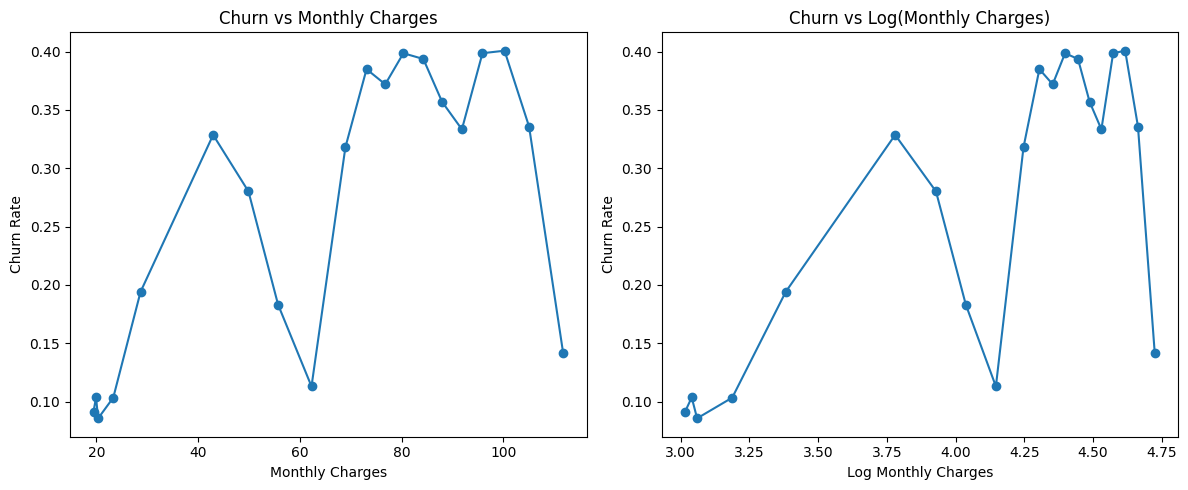

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl


# breakpoint
quantile_levels = np.linspace(0, 1, 21)[1:-1]

breaks = [
    df_fe_monthly_charges.select(
        pl.col("MonthlyCharges").quantile(float(q))
    ).item()
    for q in quantile_levels
]

# Create plotting dataset
df_plot = df_fe_monthly_charges.with_columns(
    pl.col("MonthlyCharges").cut(breaks=breaks).alias("charge_bin"),
    (pl.col("MonthlyCharges") + 1).log().alias("MonthlyCharges_log"),
    (pl.col("Churn") == "Yes").cast(pl.Int8).alias("ChurnFlag")
)

# Aggregate for original scale
df_churn = (
    df_plot.group_by("charge_bin")
    .agg(
        pl.col("ChurnFlag").mean().alias("churn_rate"),
        pl.col("MonthlyCharges").mean().alias("avg_charge")
    )
    .sort("avg_charge")
)

# Aggregate for log scale
df_churn_log = (
    df_plot.group_by("charge_bin")
    .agg(
        pl.col("ChurnFlag").mean().alias("churn_rate"),
        pl.col("MonthlyCharges_log").mean().alias("avg_charge_log")
    )
    .sort("avg_charge_log")
)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(df_churn["avg_charge"], df_churn["churn_rate"], marker="o")
axes[0].set_title("Churn vs Monthly Charges")
axes[0].set_xlabel("Monthly Charges")
axes[0].set_ylabel("Churn Rate")

axes[1].plot(df_churn_log["avg_charge_log"], df_churn_log["churn_rate"], marker="o")
axes[1].set_title("Churn vs Log(Monthly Charges)")
axes[1].set_xlabel("Log Monthly Charges")
axes[1].set_ylabel("Churn Rate")

plt.tight_layout()
plt.show()

The relationship between `MonthlyCharges` and churn does not exhibit a clear functional form.

The observed pattern is irregular, with noticeable fluctuations across different charge levels. Applying a logarithmic transformation does not meaningfully change this behavior, indicating that the issue is not due to simple non-linearity.

This suggests that `MonthlyCharges` is a composite variable influenced by multiple underlying factors, such as the combination of subscribed services and pricing structures. As a result, similar charge levels may correspond to different customer profiles with distinct churn behaviors.

Given this, no transformation is applied, and `MonthlyCharges` is retained in its original form. The variable will be interpreted in conjunction with other features rather than in isolation.

### Interaction with Service Usage

The previous analysis showed that `MonthlyCharges` does not exhibit a clear standalone relationship with churn, likely due to its dependence on the number and type of subscribed services.

To address this, interaction terms between `MonthlyCharges` and service-related variables are introduced. This allows the model to capture differences in how pricing affects customers depending on their level of service usage.

In particular, the interaction between monthly charges and the number of additional and streaming services is considered. This reflects the idea that the same price may have different implications for customers with different service bundles.

The extended model is then compared to the baseline to evaluate whether these interactions provide additional explanatory value.

In [43]:
# creating interaction features
df_fe_monthly_charges = df_fe_monthly_charges.with_columns(
    (pl.col("MonthlyCharges") * pl.col("AdditionalInternetServicesCount"))
    .alias("MC_x_Additional"),
    
    (pl.col("MonthlyCharges") * pl.col("StreamingServicesCount"))
    .alias("MC_x_Streaming")
)

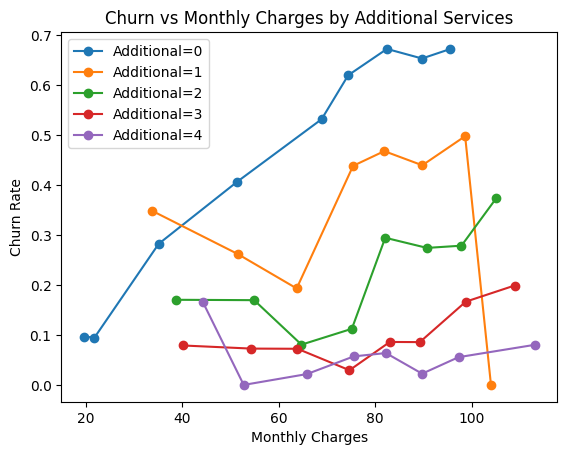

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Create bins for MonthlyCharges
quantiles = np.linspace(0, 1, 11)[1:-1]

breaks = [
    df_fe_monthly_charges.select(
        pl.col("MonthlyCharges").quantile(float(q))
    ).item()
    for q in quantiles
]

df_plot = df_fe_monthly_charges.with_columns(
    pl.col("MonthlyCharges").cut(breaks=breaks).alias("charge_bin"),
    (pl.col("Churn") == "Yes").cast(pl.Int8).alias("ChurnFlag")
)

df_grouped = (
    df_plot.group_by(["charge_bin", "AdditionalInternetServicesCount"])
    .agg(
        pl.col("ChurnFlag").mean().alias("churn_rate"),
        pl.col("MonthlyCharges").mean().alias("avg_charge")
    )
    .sort("avg_charge")
)

plt.figure()

for level in df_grouped["AdditionalInternetServicesCount"].unique():
    subset = df_grouped.filter(
        pl.col("AdditionalInternetServicesCount") == level
    )
    
    plt.plot(
        subset["avg_charge"],
        subset["churn_rate"],
        marker="o",
        label=f"Additional={level}"
    )

plt.xlabel("Monthly Charges")
plt.ylabel("Churn Rate")
plt.title("Churn vs Monthly Charges by Additional Services")
plt.legend()

plt.show()

The interaction plot does not show a clean and stable pattern across all service levels. Apart from customers with no additional services, the remaining groups appear noisy, which is likely due to smaller numbers of observations within each combination of service count and charge range.

This makes the visual evidence inconclusive. However, the differences between groups still suggest that the effect of `MonthlyCharges` may depend on the level of subscribed services.

For this reason, the interaction will be evaluated directly within the model, where its contribution can be assessed more reliably.

In [45]:
baseline_cat = []

baseline_num = ["MonthlyCharges", "AdditionalInternetServicesCount", "StreamingServicesCount", "MC_x_Additional", "MC_x_Streaming"]

model_11_cat = []

model_11_num = ["MonthlyCharges", "AdditionalInternetServicesCount", "StreamingServicesCount"]

cv_model_11 = cross_validate_logit(
    df=df_fe_monthly_charges,
    target_col="Churn",
    categorical_cols=model_11_cat,
    numerical_cols=model_11_num,
    baseline_categorical_cols=baseline_cat,
    baseline_numerical_cols=baseline_num,
    n_splits=5,
    random_state=42
)

cv_model_11

fold,auc,bic,llf,baseline_auc,baseline_bic,baseline_llf,lr_stat,lr_df_diff,lr_p_value
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,0.755647,4479.781515,-2223.063984,0.764307,4451.156973,-2200.338326,45.451316,2.0,1.3501e-10
2,0.742739,4446.403758,-2206.375105,0.747057,4423.471649,-2186.495663,39.758884,2.0,2.3252e-9
3,0.744725,4447.02415,-2206.685301,0.750905,4423.005579,-2186.262628,40.845346,2.0,1.3507e-9
4,0.777717,4515.109096,-2240.727774,0.781441,4484.948316,-2217.233997,46.987555,2.0,6.2630e-11
5,0.756544,4486.023809,-2226.184687,0.769045,4460.559293,-2205.03882,42.291734,2.0,6.5534e-10


In [46]:
import pandas as pd # used here for easier display of model summary with feature names; statsmodels itself can work without pandas
import statsmodels.api as sm

X, feature_names = build_matrix(
    df_fe_monthly_charges,
    categorical_cols=[],
    numerical_cols=[
        "MonthlyCharges",
        "AdditionalInternetServicesCount",
        "StreamingServicesCount",
        "MC_x_Additional",
        "MC_x_Streaming"
    ]
)

y = (
    df_fe_monthly_charges["Churn"]
    .eq("Yes")
    .cast(pl.Int8)
    .to_numpy()
)

X = sm.add_constant(X, has_constant="add")

X_df = pd.DataFrame(X, columns=["const"] + feature_names)

model = sm.Logit(y, X_df).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.488017
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5628
Method:                           MLE   Df Model:                            5
Date:                Wed, 25 Mar 2026   Pseudo R-squ.:                  0.1565
Time:                        12:14:35   Log-Likelihood:                -2749.5
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                2.204e-218
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -2.9436      0.113    -26.070  

The interaction terms indicate that the effect of `MonthlyCharges` on churn decreases as the number of services increases.

While higher charges are associated with increased churn, this effect is substantially reduced for customers with more services. At higher service levels, the relationship becomes much weaker, though not entirely eliminated.

This suggests that customers with more extensive service bundles are less sensitive to price, but price still plays a role.

The interaction between `MonthlyCharges` and service usage captures the key dependency in how pricing affects churn.

Additional interaction terms were considered, but given the already improved performance and clear interpretability of the current model, further extensions were not pursued to avoid unnecessary complexity.

The final specification balances predictive performance with interpretability, retaining only interactions that provide meaningful value.

## Conclusion

The `MonthlyCharges` variable was initially difficult to interpret due to its composite nature, as it reflects both the number and type of subscribed services.

Simple transformations, such as logarithmic scaling, did not improve model performance or clarify the relationship with churn. Visual analysis confirmed that the relationship is irregular rather than smoothly non-linear, suggesting that the issue lies in the structure of the variable rather than its scale.

To address this, interaction terms between `MonthlyCharges` and service-related features were introduced. This allowed the model to account for differences in how pricing affects customers depending on their level of service usage.

The results show that these interactions significantly improve model fit and predictive performance. In particular, the effect of monthly charges on churn is not constant: higher prices are associated with increased churn, but this effect is substantially reduced for customers with more services.

This explains the previously observed irregular patterns and highlights that price sensitivity is conditional on customer engagement.

Given these findings, `MonthlyCharges` is retained in its original form, and interaction terms with service usage are included in the final model. No additional transformations or interactions were found to provide meaningful improvement beyond this structure.

Overall, this approach captures the underlying relationship more effectively while maintaining interpretability.

In [47]:
df_fe_monthly_charges_end = df_fe_monthly_charges.drop([
    "MonthlyCharges_log"
])

df_fe_monthly_charges_end.write_csv("data/processed/05_fe_train_df_monthly_charges.csv")

In [48]:
df_fe_monthly_charges_end.columns

['SeniorCitizenRelevel',
 'Partner',
 'Dependents',
 'tenure',
 'InternetService',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'Churn',
 'AdditionalInternetServicesCount',
 'StreamingServicesCount',
 'MC_x_Additional',
 'MC_x_Streaming']

## Automated Feature Engineering

In this section, the dataset is prepared for different modeling approaches.

So far, feature engineering decisions were guided by domain knowledge and exploratory analysis. However, different model types benefit from different representations of the data.

In particular, linear models rely on explicit relationships between variables and require careful handling of continuous features and interaction terms. Other models, such as support vector machines and neural networks, share similar requirements, particularly with respect to continuous inputs and scaling.

In contrast, tree-based models are able to capture non-linearities and interactions automatically, and do not require scaling or explicitly defined interaction terms.

For this reason, two versions of the dataset are constructed:

- a linear model dataset, with explicitly defined interaction terms  
- a tree-based dataset, without interaciton terms

The linear dataset serves as a base representation, with normalization applied as an additional preprocessing step for models that require it.

This separation allows each model type to operate on a representation that best matches its assumptions and strengths, while keeping the overall preprocessing pipeline consistent.

In [49]:
df_fe_automated = df_fe_monthly_charges_end
df_fe_automated.columns

['SeniorCitizenRelevel',
 'Partner',
 'Dependents',
 'tenure',
 'InternetService',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'Churn',
 'AdditionalInternetServicesCount',
 'StreamingServicesCount',
 'MC_x_Additional',
 'MC_x_Streaming']

### Variable Treatment Overview

The following table summarizes how each variable is handled across the two dataset representations. The linear dataset is designed for models that require explicit structure and interpretability, while the tree-based dataset is adapted to models that can capture non-linear relationships automatically.

| Variable                          | Linear Dataset    | Tree Dataset  | Transformation | Notes |
|----------------                   |-------------      |-------------  |----------------|------|
| SeniorCitizenRelevel              | ✔                | ✔             | None | Binary variable, no change needed |
| Partner                           | ✔                | ✔            | None | Binary variable, no change needed |
| Dependents                        | ✔                | ✔            | None | Binary variable, no change needed |
| tenure                            | ✔                | ✔            | None | Continuous form preferred for linear models and many Trees algorithms |
| Contract                          | ✔                | ✔            | None | Strong categorical predictor from EDA|
| PaperlessBilling                  | ✔                | ✔            | None | Binary variable |
| PaymentMethod                     | ✔                | ✔            | Optional releveling | Grouping considered if statistically justified |
| MonthlyCharges                    | ✔                | ✔    | None| Interaction used in linear model |
| AdditionalInternetServicesCount   | ✔ (numeric)      | ✔ (ordinal)  | None | Small discrete range |
| StreamingServicesCount            | ✔ (numeric)      | ✔ (ordinal)  | None | Small discrete range |
| MC_x_Additional                   | ✔                | ✘            | Interaction term | Improves linear model |
| MC_x_Streaming                    | ✔                | ✘            | Interaction term | Improves linear model |
| Churn                             | Target            | Target        | None | Dependent variable |

### Releveling Strategy

For categorical variables with multiple levels, releveling is considered where there is potential redundancy or where categories may exhibit similar behavior.

Rather than applying arbitrary grouping, releveling decisions are evaluated using a model-based approach. Specifically, alternative representations of a variable are compared using the established cross-validation framework, assessing differences in model performance through AUC, BIC, and likelihood ratio tests where applicable.

A simplified representation is retained only if it does not lead to a statistically significant loss of information or predictive performance.

This ensures that any reduction in category levels is both justified and consistent with the overall modeling approach.

### Releveling of `PaymentMethod`

The variable `PaymentMethod` contains four categories representing different ways customers pay for the service.

From the exploratory analysis, it is clear that there are substantial differences in churn behavior across these categories. In particular, customers using "Electronic check" exhibit a significantly higher churn rate (45.29%) compared to all other payment methods, which have churn rates in the range of approximately 15–19%.

A chi-square test confirms a strong association between `PaymentMethod` and churn (p-value < 0.001). However, the observed differences are not uniform across categories. While "Electronic check" stands out as a distinct high-churn group, the remaining payment methods show relatively similar behavior.

This suggests that a meaningful simplification may be possible by separating "Electronic check" from the rest, rather than grouping payment methods purely based on whether they are automatic or manual.

To evaluate this, alternative representations of `PaymentMethod` are tested using the established modeling framework. The goal is to determine whether a reduced number of categories can retain the predictive information while simplifying the variable structure.

Two candidate groupings are considered:

- **Electronic check vs Other**  
- **Electronic check vs Automatic (bank transfer and credit card) vs Mailed check**

In [50]:
df_fe_automated = df_fe_automated.with_columns(

    # Candidate 1: Electronic vs Other
    pl.when(pl.col("PaymentMethod") == "Electronic check")
    .then(pl.lit("Electronic check"))
    .otherwise(pl.lit("Other"))
    .alias("PaymentMethod_bin_2"),

    # Candidate 2: Electronic / Automatic / Mailed
    pl.when(pl.col("PaymentMethod") == "Electronic check")
    .then(pl.lit("Electronic check"))
    .when(
        pl.col("PaymentMethod").is_in([
            "Bank transfer (automatic)",
            "Credit card (automatic)"
        ])
    )
    .then(pl.lit("Automatic"))
    .otherwise(pl.lit("Mailed check"))
    .alias("PaymentMethod_bin_3")
)

In [51]:
baseline_cat = ["PaymentMethod"]
baseline_num = []

model_cat = ["PaymentMethod_bin_2"]
model_num = []

cv_payment_method_bin_2 = cross_validate_logit(
    df=df_fe_automated,
    target_col="Churn",
    categorical_cols=model_cat,
    numerical_cols=model_num,
    baseline_categorical_cols=baseline_cat,
    baseline_numerical_cols=baseline_num,
    n_splits=5,
    random_state=42
)

cv_payment_method_bin_2

fold,auc,bic,llf,baseline_auc,baseline_bic,baseline_llf,lr_stat,lr_df_diff,lr_p_value
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,0.329292,4822.109397,-2402.641312,0.613088,4835.697494,-2401.021973,3.238677,2.0,0.19803
2,0.653521,4801.71819,-2392.445708,0.347095,4809.613343,-2387.979898,8.931621,2.0,0.011495
3,0.328317,4826.045927,-2404.609576,0.560629,4830.327273,-2398.336863,12.545428,2.0,0.001887
4,0.344528,4804.912384,-2394.042805,0.566534,4814.175597,-2390.261025,7.563561,2.0,0.022782
5,0.324932,4829.552899,-2406.36284,0.570307,4837.481936,-2401.91375,8.89818,2.0,0.011689


In [52]:
baseline_cat = ["PaymentMethod"]
baseline_num = []

model_cat = ["PaymentMethod_bin_3"]
model_num = []

cv_payment_method_bin_3 = cross_validate_logit(
    df=df_fe_automated,
    target_col="Churn",
    categorical_cols=model_cat,
    numerical_cols=model_num,
    baseline_categorical_cols=baseline_cat,
    baseline_numerical_cols=baseline_num,
    n_splits=5,
    random_state=42
)

cv_payment_method_bin_3

fold,auc,bic,llf,baseline_auc,baseline_bic,baseline_llf,lr_stat,lr_df_diff,lr_p_value
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,0.607575,4827.606441,-2401.18314,0.613088,4835.697494,-2401.021973,0.322333,1.0,0.570209
2,0.351825,4801.538488,-2388.149163,0.347095,4809.613343,-2387.979898,0.338532,1.0,0.560678
3,0.560982,4823.488541,-2399.12419,0.560629,4830.327273,-2398.336863,1.574655,1.0,0.209532
4,0.567338,4807.462073,-2391.110956,0.566534,4814.175597,-2390.261025,1.699863,1.0,0.192306
5,0.569583,4830.28661,-2402.522892,0.570307,4837.481936,-2401.91375,1.218283,1.0,0.269698


The two candidate groupings of `PaymentMethod` were evaluated using the cross-validation framework.

The binary grouping (Electronic check vs Other) results in a noticeable decrease in predictive performance. AUC values are consistently lower compared to the original variable, and the likelihood ratio test is significant in most folds, indicating a loss of information. This suggests that grouping all non-electronic payment methods together is too coarse and fails to capture meaningful differences between them.

In contrast, the three-level grouping (Electronic check vs Automatic vs Mailed check) performs comparably to the original variable. AUC values remain similar, BIC is consistently lower, and the likelihood ratio test is not significant in any fold. This indicates that the simplified representation retains the predictive information while reducing model complexity.

These results confirm that while "Electronic check" represents a distinct high-churn group, the remaining categories still contain relevant differences that should not be fully collapsed.

Therefore, the three-level representation is retained as the final form of the `PaymentMethod` variable.

In [53]:
df_fe_automated = df_fe_automated.drop("PaymentMethod", "PaymentMethod_bin_2")

### Treatment of `Contract`

Although `Contract` is a multi-level categorical variable, releveling is not considered in this case.

From the exploratory analysis, it is evident that all three categories exhibit clearly distinct churn behavior:

- Month-to-month: 42.64% churn  
- One year: 11.08% churn  
- Two year: 2.68% churn  

The differences are substantial and follow a clear monotonic pattern, with longer contracts strongly associated with lower churn.

A chi-square test confirms a very strong association between `Contract` and churn (p-value < 0.001), indicating that each category carries meaningful and distinct information.

Given this, any attempt to merge categories would result in a significant loss of information. Therefore, the original representation of the variable is retained without modification.

In [54]:
df_fe_linear = df_fe_automated.select(['SeniorCitizenRelevel',
                                        'Partner',
                                        'Dependents',
                                        'tenure',
                                        'Contract',
                                        'PaperlessBilling',
                                        'MonthlyCharges',
                                        'Churn',
                                        'AdditionalInternetServicesCount',
                                        'StreamingServicesCount',
                                        'MC_x_Additional',
                                        'MC_x_Streaming',
                                        'PaymentMethod_bin_3'])

df_fe_tree = df_fe_automated.select(['SeniorCitizenRelevel',
                                    'Partner',
                                    'Dependents',
                                    'tenure',
                                    'Contract',
                                    'PaperlessBilling',
                                    'MonthlyCharges',
                                    'Churn',
                                    'AdditionalInternetServicesCount',
                                    'StreamingServicesCount',
                                    'PaymentMethod_bin_3'])

In [55]:
df_fe_linear.columns

['SeniorCitizenRelevel',
 'Partner',
 'Dependents',
 'tenure',
 'Contract',
 'PaperlessBilling',
 'MonthlyCharges',
 'Churn',
 'AdditionalInternetServicesCount',
 'StreamingServicesCount',
 'MC_x_Additional',
 'MC_x_Streaming',
 'PaymentMethod_bin_3']

In [56]:
df_fe_tree.columns

['SeniorCitizenRelevel',
 'Partner',
 'Dependents',
 'tenure',
 'Contract',
 'PaperlessBilling',
 'MonthlyCharges',
 'Churn',
 'AdditionalInternetServicesCount',
 'StreamingServicesCount',
 'PaymentMethod_bin_3']

### Autmated Feature Engeneering conclusion

In this section, we prepared datasets to support different modeling approaches by adapting the representation of selected variables.

Continuous variables such as `tenure` and `MonthlyCharges` were transformed into binned versions for tree-based models, allowing them to capture non-linear patterns more effectively. At the same time, their original continuous forms were preserved for linear models, where explicit structure and interaction terms provide better interpretability.

Although this step is referred to as automated feature engineering, the process remained guided by insights obtained from exploratory analysis and prior modeling results. Rather than relying on fully automated transformations, simple and transparent methods were applied to ensure consistency and interpretability.

This results in two complementary dataset representations, each aligned with the assumptions of the respective model classes, while maintaining a coherent and well-justified feature engineering pipeline.

## Final Conclusion

In this chapter, the feature engineering process was carried out through a combination of exploratory analysis, domain understanding, and model-based validation.

Initial transformations focused on simplifying complex groups of variables, particularly in the case of internet services. These were reduced to a small number of interpretable features that retained the essential information while avoiding unnecessary complexity. Subsequent analysis confirmed that further simplification would lead to a loss of predictive power, supporting the final structure.

Categorical variables were examined individually, with releveling applied only where justified by both exploratory analysis and statistical testing. In some cases, such as `PaymentMethod`, meaningful simplifications were identified and validated. In others, such as `Contract`, the original structure was retained due to clearly distinct and informative category behavior.

Although parts of this process are referred to as automated feature engineering, the final result remains strongly guided by prior analysis and modeling results. Rather than relying on fully automated procedures, transformations were chosen deliberately to balance predictive performance, interpretability, and consistency.

The outcome is two well-defined dataset representations: one tailored to linear and related models, and another adapted for tree-based methods. Together, they provide a robust foundation for the modeling phase, ensuring that each model operates on a representation aligned with its underlying assumptions.

In [57]:
df_fe_automated.write_csv("data/processed/05_fe_train_df_end.csv")

In [58]:
import json

# due to changes to non trivial changes to the features AdditionalInternetServicesCount and StreamingServicesCount and interaction terms, the feature config is split into four parts:

feature_config_1 = {
    "new_features": [        
        {   "name": "OnlineSecurityNumeric",
            "source":{"name": "OnlineSecurity",
                      "data_type": "string"},
            "data_type": "numeric",
            "action": "relevel",
            "mapping": {"Yes": 1, 
                        "No": 0,
                        "No internet service": 0}
        },
        {   "name": "OnlineBackupNumeric",
            "source":{"name": "OnlineBackup",
                      "data_type": "string"},
            "data_type": "numeric",
            "action": "relevel",
            "mapping": {"Yes": 1, 
                        "No": 0,
                        "No internet service": 0}
        },
        {   "name": "DeviceProtectionNumeric",
            "source":{"name": "DeviceProtection",
                      "data_type": "string"},
            "data_type": "numeric",
            "action": "relevel",
            "mapping": {"Yes": 1, 
                        "No": 0,
                        "No internet service": 0}
        },
        {   "name": "TechSupportNumeric",
            "source":{"name": "TechSupport",
                      "data_type": "string"},
            "data_type": "numeric",
            "action": "relevel",
            "mapping": {"Yes": 1, 
                        "No": 0,
                        "No internet service": 0}
        },
        {   "name": "StreamingTVNumeric",
            "source":{"name": "StreamingTV",
                      "data_type": "string"},
            "data_type": "numeric",
            "action": "relevel",
            "mapping": {"Yes": 1, 
                        "No": 0,
                        "No internet service": 0}
        },
        {   "name": "StreamingMoviesNumeric",
            "source":{"name": "StreamingMovies",
                      "data_type": "string"},
            "data_type": "numeric",
            "action": "relevel",
            "mapping": {"Yes": 1, 
                        "No": 0,
                        "No internet service": 0}
        }
        ],
    "dropped_features": [
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies"]
}


feature_config_2 = {
    "new_features": [
        {"name": "AdditionalInternetServicesCount",
            "data_type": "numeric",
            "action": "aggregate_sum",
            "fields": ["OnlineSecurityNumeric",
                    "OnlineBackupNumeric",
                    "DeviceProtectionNumeric",
                    "TechSupportNumeric"]
        },
        {"name": "StreamingServicesCount",
            "data_type": "numeric",
            "action": "aggregate_sum",
            "fields": ["StreamingTVNumeric",
                    "StreamingMoviesNumeric"]
        }
        ],
    "dropped_features": [
        "OnlineSecurityNumeric",
        "OnlineBackupNumeric",
        "DeviceProtectionNumeric",
        "TechSupportNumeric",
        "StreamingTVNumeric",
        "StreamingMoviesNumeric"
    ]
}

feature_config_3 = {
    "new_features": [{"name": "MC_x_Additional",
                            "data_type": "numeric",
                            "action": "aggregate_multiply",
                            "fields": ["AdditionalInternetServicesCount",
                                    "MonthlyCharges"]
                        },
                    {"name": "MC_x_Streaming",
                            "data_type": "numeric",
                            "action": "aggregate_multiply",
                            "fields": ["StreamingServicesCount",
                                    "MonthlyCharges"]
                        }],
    "dropped_features": []
}

feature_config_4 = {
    "new_features": [{"name": "PaymentMethod_bin_3",
                        "source":{"name": "PaymentMethod",
                                "data_type": "string"},
                        "data_type": "string",
                        "action": "relevel",
                        "mapping": {
                                "Mailed check": "Mailed check",
                                "Electronic check": "Electronic check",
                                "Bank transfer (automatic)": "Automatic",
                                "Credit card (automatic)": "Automatic"
                            }
                      }],
    "dropped_features": ["PaymentMethod"]
}

with open("./data/configs/03_fe.json", "w") as f:
    json.dump(feature_config_1, f)
with open("./data/configs/04_fe.json", "w") as f:
    json.dump(feature_config_2, f)
with open("./data/configs/05_fe.json", "w") as f:
    json.dump(feature_config_3, f)
with open("./data/configs/06_fe.json", "w") as f:
    json.dump(feature_config_4, f)